In [7]:
from astropy.io import fits

oiii_hdul = fits.open("SNR_OIII.fits")
oiiic_hdul = fits.open("aligned_OIIIC.fits")

oiii_data = oiii_hdul["SCI"].data
oiiic_data = oiiic_hdul["SCI"].data

oiii_hdul.info()

Filename: SNR_OIII.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     214   ()      
  1  SCI           1 ImageHDU       148   (3164, 2175)   float32   
  2  VAR           1 ImageHDU       148   (3164, 2175)   float32   
  3  DQ            1 ImageHDU       148   (3164, 2175)   int16 (rescales to uint16)   
  4  OBJMASK       1 ImageHDU       148   (3164, 2175)   uint8   
  5  OBJCAT        1 BinTableHDU    169   8943R x 43C   [K, D, D, D, D, D, D, D, D, D, D, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, J, I, J, J, E, J, E, E, E, E]   
  6  HISTORY       1 BinTableHDU     17   18R x 4C   [128A, 288A, 28A, 28A]   
  7  PROVENANCE    1 BinTableHDU     17   9R x 4C   [28A, 128A, 128A, 128A]   


In [40]:
diff = oiii_data - oiiic_data * 0.3

In [41]:
fits.writeto("continuum_subtracted.fits", diff, header=oiii_hdul['SCI'].header, overwrite=True)

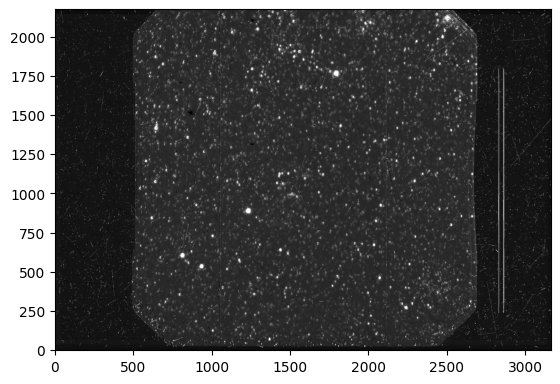

In [42]:
import matplotlib.pyplot as plt
import numpy as np

plt.imshow(diff, cmap='gray', origin='lower', vmin=np.percentile(diff,1), vmax=np.percentile(diff,99.5))
plt.show()

In [ ]:
# align OIIIC with OIII using astroalign

from astropy.io import fits
import astroalign as aa
import numpy as np

img1 = fits.getdata("SNR_OIII.fits")
img2 = fits.getdata("SNR_OIIIC.fits")

img1 = np.asarray(img1, dtype=np.float32)
img2 = np.asarray(img2, dtype=np.float32)

aligned_img2, footprint = aa.register(img2, img1)

fits.writeto("aligned_OIIIC.fits", aligned_img2, header=oiii_hdul['SCI'].header, overwrite=True)